# Tech Layoffs Analysis (2020–2025)
### A Data Analyst Portfolio Project

**Author:** Annisa Wardah Sibarani
**Tools:** Python (pandas, matplotlib, seaborn)
**Dataset:** [Tech Layoffs Dataset](https://www.kaggle.com/datasets/ulrikeherold/tech-layoffs-2020-2024), company layoffs across the global tech industry, 2020–2025

---

## 1. Background

Since 2020, the global tech industry has gone through several waves of mass layoffs. starting with the COVID-19 shock in 2020, followed by a slowdown in 2021, and then a much larger wave in 2022–2023 driven by over-hiring corrections, rising interest rates, and the shift toward AI-driven restructuring.

This project analyzes a dataset of individual layoff events (company, location, industry, funding stage, and layoff size) to understand **when, where, and which parts of the tech industry were hit hardest**, and whether there is a relationship between a company's funding stage / capital raised and the scale of its layoffs.

## 2. Objectives

This analysis aims to answer the following business questions:

1. How has the total number of layoffs trended year over year (2020–2025)? Is there a clear "wave" pattern?
2. Which countries and regions have been most affected by tech layoffs?
3. Which industries have suffered the largest layoffs?
4. Is there a relationship between a company's funding stage (e.g. Seed, Series A–F, Post-IPO) and the severity of its layoffs?
5. Is there a relationship between capital raised and the percentage of the workforce laid off?
6. Which specific companies had the largest single layoff events?

## 3. Dataset Overview

The primary file used is `Cleaned_tech_layoffs.csv`, which contains **1,745 layoff events** with the following key columns:

| Column | Description |
|---|---|
| `Company` | Name of the company |
| `Location_HQ`, `Region`, `USState`, `Country`, `Continent` | Geographic information |
| `Laid_Off` | Number of employees laid off in this event |
| `Date_layoffs` | Date the layoff was announced |
| `Percentage` | Percentage of total workforce laid off |
| `Company_Size_before_Layoffs` / `_after_layoffs` | Headcount before/after |
| `Industry` | Industry sector |
| `Stage` | Company funding/maturity stage (e.g. Seed, Series A, Post-IPO, Acquired) |
| `Money_Raised_in__mil` | Total capital raised by the company (USD millions) |
| `Year` | Year of the layoff |

A secondary, larger but less complete file (`tech_layoffs_til_2025.csv`) is used briefly in Section 4 as a cross-check.


## 4. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/Cleaned_tech_layoffs.csv")
df.shape


(1745, 18)

In [2]:
df.head()


,Nr,Company,Location_HQ,Region,USState,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in__mil,Year,latitude,longitude
0,1,Tamara Mellon,Los Angeles,other,California,USA,North America,20.0,2020-03-12,40.0,50.0,30.0,Retail,Series C,90.0,2020,34.053691,-118.242766
1,2,HopSkipDrive,Los Angeles,other,California,USA,North America,8.0,2020-03-13,10.0,80.0,72.0,Transportation,Unknown,45.0,2020,34.053691,-118.242766
2,3,Panda Squad,San Francisco,San Francisco Bay Area,California,USA,North America,6.0,2020-03-13,75.0,8.0,2.0,Consumer,Seed,1.0,2020,37.779259,-122.419329
3,4,Help.com,Austin,other,Texas,USA,North America,16.0,2020-03-16,100.0,16.0,0.0,Support,Seed,6.0,2020,30.271129,-97.743700
4,5,Inspirato,Denver,other,Colorado,USA,North America,130.0,2020-03-16,22.0,591.0,461.0,Travel,Series C,79.0,2020,39.739236,-104.984862


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1745 entries, 0 to 1744
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Nr                           1745 non-null   int64  
 1   Company                      1745 non-null   str    
 2   Location_HQ                  1745 non-null   str    
 3   Region                       1745 non-null   str    
 4   USState                      1744 non-null   str    
 5   Country                      1745 non-null   str    
 6   Continent                    1745 non-null   str    
 7   Laid_Off                     1745 non-null   float64
 8   Date_layoffs                 1745 non-null   str    
 9   Percentage                   1745 non-null   float64
 10  Company_Size_before_Layoffs  1745 non-null   float64
 11  Company_Size_after_layoffs   1745 non-null   float64
 12  Industry                     1745 non-null   str    
 13  Stage                        

### 4.1 Cross-checking against the larger raw file

Before committing to the cleaned file, let's quickly confirm it's consistent with the larger (less clean) source file in terms of scale and coverage.

In [4]:
df_raw = pd.read_csv("../data/tech_layoffs_til_2025.csv")
print("Cleaned file:", df.shape, "| Years:", df['Year'].min(), "-", df['Year'].max())
print("Raw file:    ", df_raw.shape, "| Years:", df_raw['Year'].min(), "-", df_raw['Year'].max())
print("\nMissing values in cleaned file:")
print(df.isnull().sum())


Cleaned file: (1745, 18) | Years: 2020 - 2025
Raw file:     (2412, 18) | Years: 2020 - 2025

Missing values in cleaned file:
Nr                               0
Company                          0
Location_HQ                      0
Region                           0
USState                          1
Country                          0
Continent                        0
Laid_Off                         0
Date_layoffs                     0
Percentage                       0
Company_Size_before_Layoffs      0
Company_Size_after_layoffs       0
Industry                         0
Stage                           27
Money_Raised_in__mil           110
Year                             0
latitude                         0
longitude                        0
dtype: int64


**Observation:** The cleaned file has 1,745 rows versus 2,412 in the raw file. The raw file contains more rows but far more missing values in key numeric columns (`Laid_Off`, `Percentage`, `Company_Size_*`). Since our core analysis depends on those numeric fields, we proceed with `Cleaned_tech_layoffs.csv` as the primary dataset. Only `Stage` (27 missing) and `Money_Raised_in__mil` (110 missing) have gaps, and both are handled explicitly wherever they're used.

## 5. Data Cleaning & Preparation

Even though the source file is labeled "cleaned," a few preparation steps are still needed before analysis:

1. Parse `Date_layoffs` into a proper datetime type and derive a `Month` period for time-series analysis.
2. Standardize the `Stage` column (fill missing with `"Unknown"` rather than dropping rows, dropping would remove otherwise valid layoff records).
3. Check for duplicate records.
4. Sanity-check numeric ranges (e.g. `Percentage` should be between 0 and 100).


In [5]:
# 1. Parse dates
df['Date_layoffs'] = pd.to_datetime(df['Date_layoffs'], errors='coerce')
df['Month'] = df['Date_layoffs'].dt.to_period('M').dt.to_timestamp()

# 2. Standardize Stage
df['Stage'] = df['Stage'].fillna('Unknown')

# 3. Duplicate check
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate on Company + Date:", df.duplicated(subset=['Company', 'Date_layoffs']).sum())

# 4. Sanity check on Percentage range
print("\nPercentage range:", df['Percentage'].min(), "-", df['Percentage'].max())
print("Any negative Laid_Off?", (df['Laid_Off'] < 0).any())


Duplicate rows: 0
Duplicate on Company + Date: 3

Percentage range: 0.0 - 100.0
Any negative Laid_Off? False


**Result:** No exact duplicate rows and no negative values were found. `Percentage` falls within the expected 0–100 range, so no further correction is required. The dataset is now ready for exploratory analysis.

## 6. Exploratory Data Analysis

### 6.1 Descriptive statistics for key numeric fields

In [6]:
df[['Laid_Off', 'Percentage', 'Company_Size_before_Layoffs',
    'Company_Size_after_layoffs', 'Money_Raised_in__mil']].describe()


,Laid_Off,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Money_Raised_in__mil
count,1745.000000,1745.000000,1745.000000,1745.000000,1635.000000
mean,333.355301,22.353696,4540.432092,4207.076218,736.102752
std,1188.000105,22.153103,26629.958930,25819.349236,4725.136039
min,3.000000,0.000000,4.000000,0.000000,1.000000
25%,40.000000,9.000000,220.000000,160.000000,60.000000
50%,90.000000,15.000000,575.000000,453.000000,174.000000
75%,200.000000,27.000000,1550.000000,1350.000000,461.500000
max,22000.000000,100.000000,600000.000000,588000.000000,121900.000000


**Observation:** The median layoff event affected 15 employees, but the distribution is heavily right-skewed, the largest single event laid off 22,000 employees. This tells us the total headline numbers reported in the media are usually driven by a small number of very large companies (e.g. Amazon, Meta, Google), while the bulk of events are much smaller startups.

### 6.2 Question 1, How have layoffs trended over time?

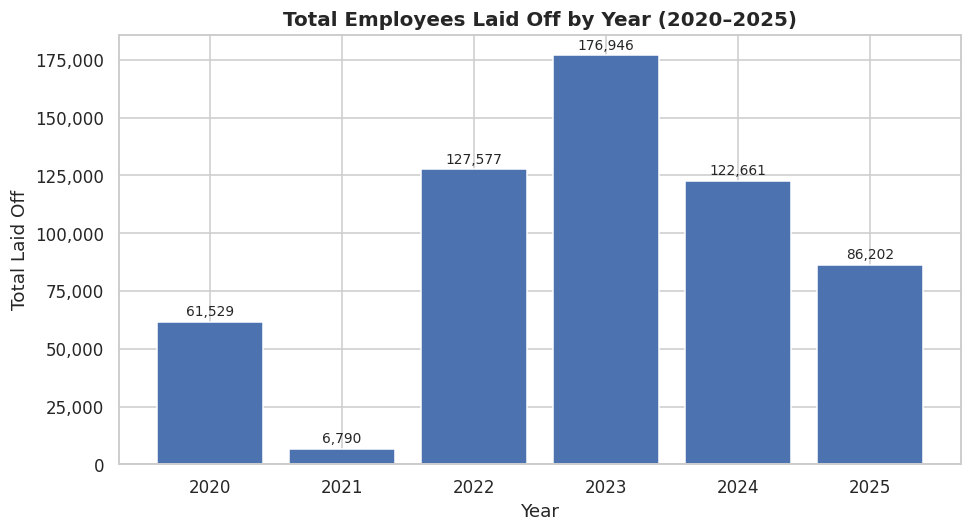

In [7]:
yearly = df.groupby('Year')['Laid_Off'].sum()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(yearly.index.astype(str), yearly.values, color=sns.color_palette("deep")[0])
ax.set_title("Total Employees Laid Off by Year (2020–2025)", fontsize=13, weight='bold')
ax.set_xlabel("Year")
ax.set_ylabel("Total Laid Off")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{int(height):,}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 4), textcoords="offset points", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


**Insight:** Layoffs spiked sharply in 2020 (COVID-19 shock), dropped to their lowest point in 2021 as the industry stabilized and hiring boomed, then surged again, peaking in 2023, as companies corrected for pandemic-era over-hiring amid rising interest rates. 2024–2025 remain elevated compared to 2021, suggesting the industry has not fully returned to pre-correction hiring levels, likely compounded by AI-driven restructuring of teams.

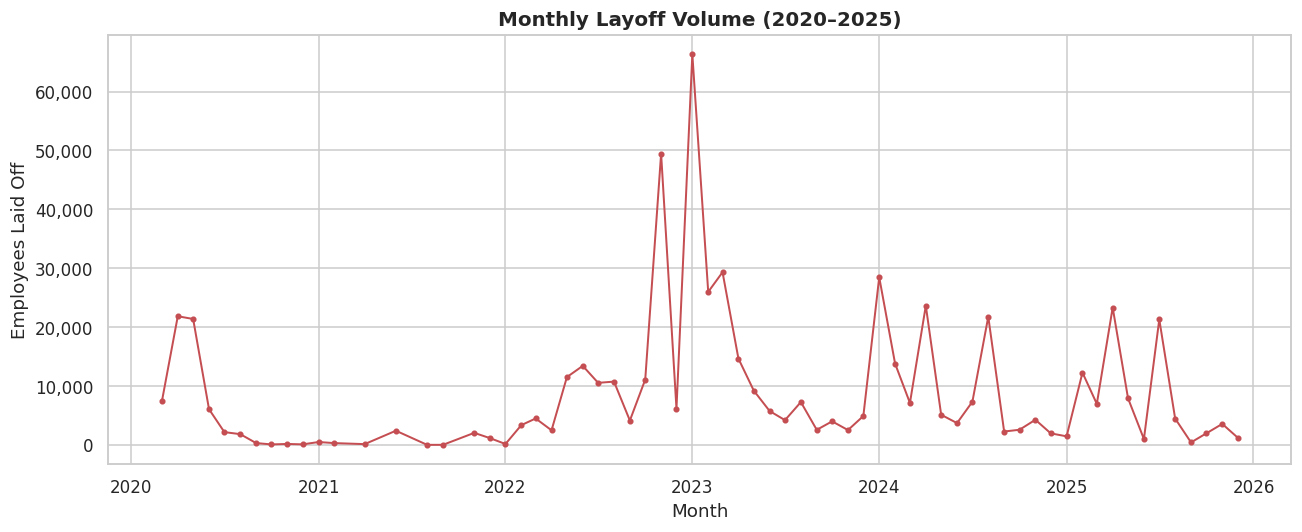

In [8]:
monthly = df.groupby('Month')['Laid_Off'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly.index, monthly.values, marker='o', markersize=3, linewidth=1.3,
        color=sns.color_palette("deep")[3])
ax.set_title("Monthly Layoff Volume (2020–2025)", fontsize=13, weight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Employees Laid Off")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


**Insight:** At monthly resolution, the trend shows distinct spikes rather than smooth growth, layoffs tend to cluster around specific months (often January and the start of a new fiscal year, when many companies reset headcount plans), rather than being evenly distributed throughout the year.

### 6.3 Question 2, Which countries and regions are most affected?

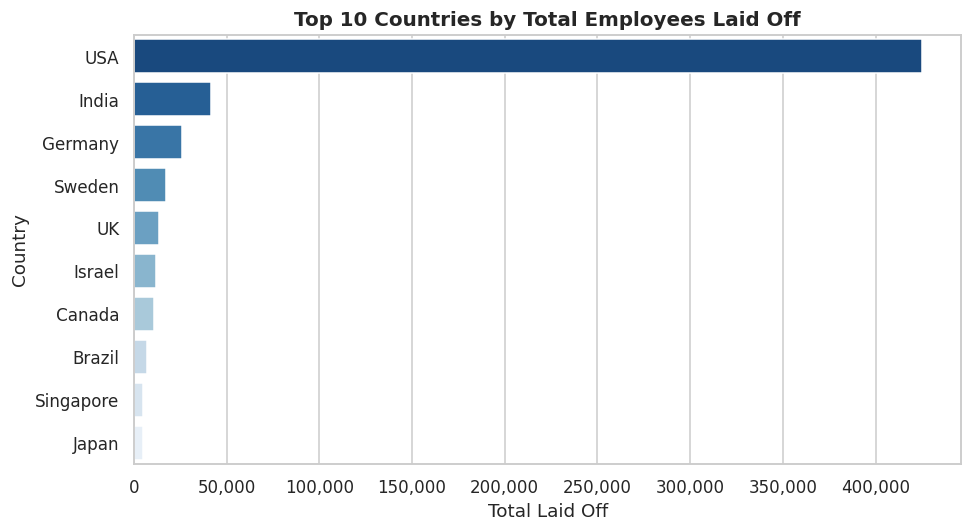

In [9]:
top_countries = df.groupby('Country')['Laid_Off'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax,
            palette="Blues_r", hue=top_countries.index, legend=False)
ax.set_title("Top 10 Countries by Total Employees Laid Off", fontsize=13, weight='bold')
ax.set_xlabel("Total Laid Off")
ax.set_ylabel("Country")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


In [10]:
continent_share = df.groupby('Continent')['Laid_Off'].sum().sort_values(ascending=False)
share_pct = (continent_share / continent_share.sum() * 100).round(1)
share_pct


Continent
North America    75.0
Asia             12.0
Europe           10.7
South America     1.3
Oceana            0.6
Africa            0.4
Name: Laid_Off, dtype: float64

**Insight:** The United States dominates total layoff volume by a wide margin, consistent with it being home to the largest concentration of major tech employers (Amazon, Meta, Google, Microsoft, etc.). India ranks second, reflecting the size of global tech companies' offshore engineering and support hubs. By continent, North America accounts for the large majority of layoffs, followed by Asia and Europe, this mirrors where large-scale tech operations, not just headquarters, are concentrated.

### 6.4 Question 3, Which industries were hit hardest?

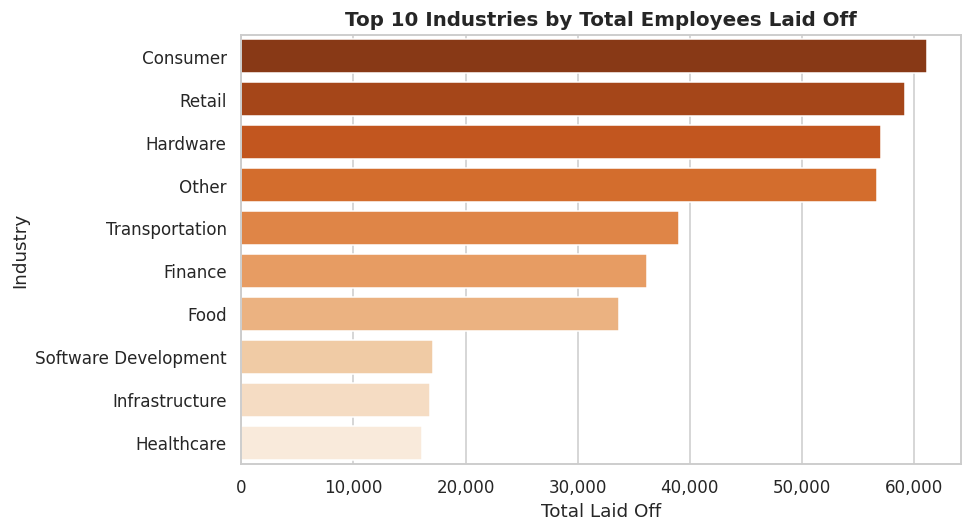

In [11]:
top_industries = df.groupby('Industry')['Laid_Off'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_industries.values, y=top_industries.index, ax=ax,
            palette="Oranges_r", hue=top_industries.index, legend=False)
ax.set_title("Top 10 Industries by Total Employees Laid Off", fontsize=13, weight='bold')
ax.set_xlabel("Total Laid Off")
ax.set_ylabel("Industry")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


**Insight:** Finance, Retail, and Healthcare-adjacent tech companies show some of the highest cumulative layoffs, a reminder that "tech layoffs" datasets like this one capture the tech *divisions and tech-enabled companies* across many sectors, not only pure software firms. This is useful context: a company labeled under "Finance" here is typically a fintech, not a traditional bank.

### 6.5 Question 4, Does funding stage relate to layoff severity?

In [12]:
stage_order = ['Seed', 'Series A', 'Series B', 'Series C', 'Series D',
               'Series E', 'Series F', 'Series G', 'Series H', 'Series I',
               'Private Equity', 'Acquired', 'Post-IPO', 'Subsidiary', 'Unknown']

stage_stats = (df.groupby('Stage')
                 .agg(events=('Company', 'count'),
                      total_laid_off=('Laid_Off', 'sum'),
                      avg_percentage=('Percentage', 'mean'))
                 .reindex([s for s in stage_order if s in df['Stage'].unique()])
                 .dropna(how='all'))
stage_stats


,events,total_laid_off,avg_percentage
Stage,,,
Seed,28,1200.0,55.892857
Series A,99,4906.0,34.919192
Series B,220,24403.0,29.536364
Series C,188,18030.0,22.680851
Series D,177,20958.0,18.762712
Series E,107,17208.0,17.090654
Series F,55,9357.0,13.400000
Series G,16,4594.0,16.812500
Series H,23,7131.0,11.200000


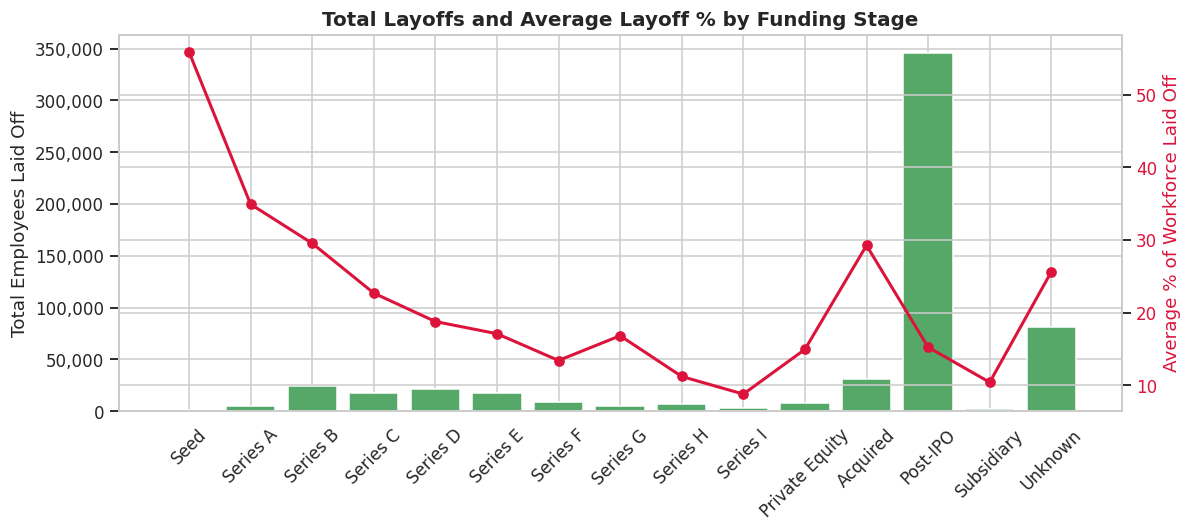

In [13]:
fig, ax1 = plt.subplots(figsize=(11, 5))
stages_plot = stage_stats.dropna(subset=['total_laid_off'])
ax1.bar(stages_plot.index, stages_plot['total_laid_off'], color=sns.color_palette("deep")[2])
ax1.set_ylabel("Total Employees Laid Off")
ax1.set_title("Total Layoffs and Average Layoff % by Funding Stage", fontsize=13, weight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

ax2 = ax1.twinx()
ax2.plot(stages_plot.index, stages_plot['avg_percentage'], color='crimson',
         marker='o', linewidth=2, label='Avg % of workforce laid off')
ax2.set_ylabel("Average % of Workforce Laid Off", color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
plt.tight_layout()
plt.show()


**Insight:** Post-IPO companies (large, publicly listed firms) account for the largest *absolute* number of employees laid off, unsurprising, since they simply employ far more people. However, when looking at the *average percentage of workforce cut per event*, early-stage companies (Seed, Series A/B) tend to cut a larger share of their (smaller) teams relative to their size, a single layoff round at an early-stage startup is more likely to be an existential correction than a large public company trimming a small percentage of a much bigger base.

### 6.6 Question 5, Does capital raised relate to layoff severity?

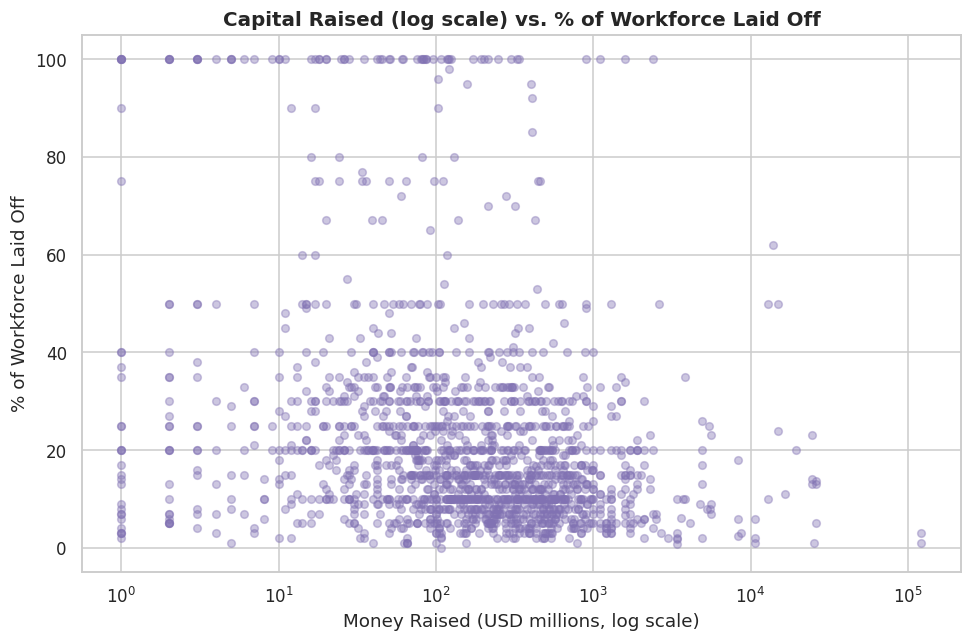

Correlation (capital raised vs. % laid off): -0.062


In [14]:
scatter_df = df.dropna(subset=['Money_Raised_in__mil', 'Percentage'])
scatter_df = scatter_df[scatter_df['Money_Raised_in__mil'] > 0]

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(scatter_df['Money_Raised_in__mil'], scatter_df['Percentage'],
           alpha=0.4, s=25, color=sns.color_palette("deep")[4])
ax.set_xscale('log')
ax.set_title("Capital Raised (log scale) vs. % of Workforce Laid Off", fontsize=13, weight='bold')
ax.set_xlabel("Money Raised (USD millions, log scale)")
ax.set_ylabel("% of Workforce Laid Off")
plt.tight_layout()
plt.show()

corr = scatter_df[['Money_Raised_in__mil', 'Percentage']].corr().iloc[0, 1]
print(f"Correlation (capital raised vs. % laid off): {corr:.3f}")


**Insight:** The correlation between capital raised and the percentage of workforce laid off is weak, and the scatter plot shows no clear linear pattern. This suggests that **how much money a company has raised is not, by itself, a strong predictor of how severely it will cut staff**, well-funded companies can still make deep cuts, and lightly-funded ones don't always cut more. Layoff severity is likely driven more by factors not captured here, such as burn rate, revenue trajectory, and specific market conditions.

### 6.7 Question 6, Which companies had the largest single layoff events?

In [15]:
top_events = df.nlargest(10, 'Laid_Off')[
    ['Company', 'Country', 'Industry', 'Stage', 'Date_layoffs', 'Laid_Off', 'Percentage']
].reset_index(drop=True)
top_events


,Company,Country,Industry,Stage,Date_layoffs,Laid_Off,Percentage
0,Intel,USA,Hardware,Post-IPO,2025-04-23,22000.0,20.0
1,Intel,USA,Hardware,Post-IPO,2024-08-01,15000.0,15.0
2,Tesla,USA,Motor Vehicle Manufacturing,Unknown,2024-04-15,14000.0,10.0
3,Google,USA,Consumer,Post-IPO,2023-01-20,12000.0,6.0
4,TCS,India,IT Services and IT Consulting,Unknown,2025-07-27,12000.0,2.0
5,Meta,USA,Consumer,Post-IPO,2022-11-09,11000.0,13.0
6,Amazon,USA,Retail,Post-IPO,2022-11-16,10000.0,3.0
7,Microsoft,USA,Software Development,Post-IPO,2023-01-18,10000.0,5.0
8,Meta,USA,Consumer,Post-IPO,2023-03-14,10000.0,13.6
9,Amazon,USA,Retail,Post-IPO,2023-03-20,9000.0,2.3


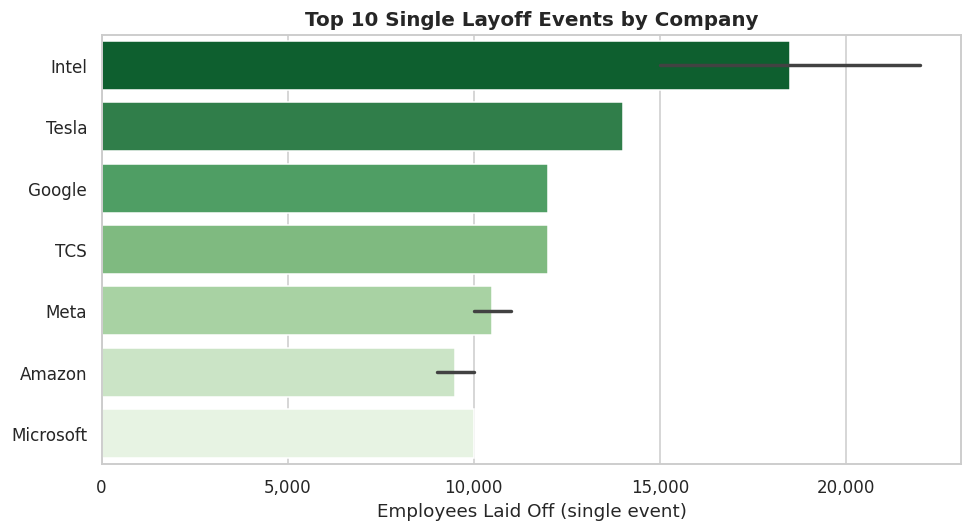

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=top_events, x='Laid_Off', y='Company', palette="Greens_r",
            hue='Company', legend=False, ax=ax)
ax.set_title("Top 10 Single Layoff Events by Company", fontsize=13, weight='bold')
ax.set_xlabel("Employees Laid Off (single event)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


**Insight:** The largest single events are dominated by a handful of mega-cap, Post-IPO companies. These few events alone account for a disproportionate share of total layoffs in the dataset, reinforcing the earlier point that headline "tech industry" layoff totals are driven by a small number of very large companies, not a broad, even wave of cuts across thousands of firms.

### 6.8 Correlation Between Numeric Variables

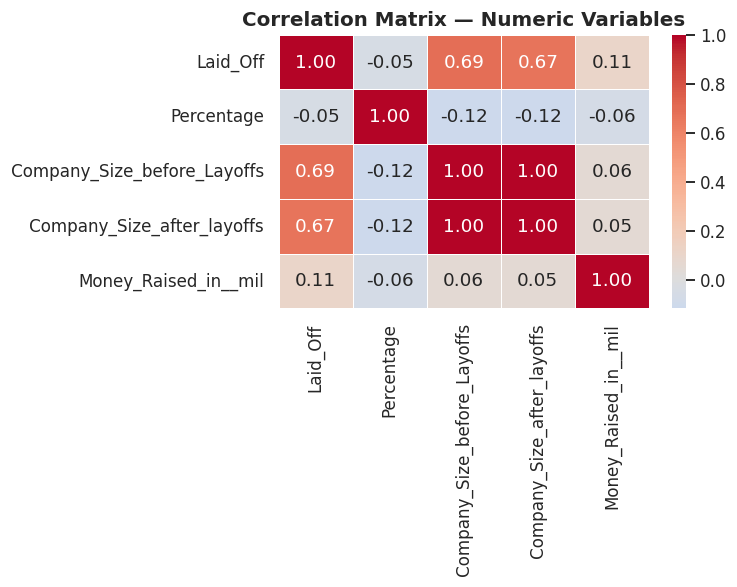

In [17]:
num_cols = ['Laid_Off', 'Percentage', 'Company_Size_before_Layoffs',
            'Company_Size_after_layoffs', 'Money_Raised_in__mil']
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            linewidths=0.5)
ax.set_title("Correlation Matrix, Numeric Variables", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()


**Insight:** `Company_Size_before_Layoffs` and `Company_Size_after_layoffs` are, unsurprisingly, almost perfectly correlated. `Laid_Off` correlates moderately with company size (bigger companies produce bigger absolute layoff numbers), but `Percentage` (the relative severity) shows very weak correlation with company size or money raised, confirming that **the relative depth of a layoff is largely independent of how big or well-funded a company is.**

## 7. Summary of Key Insights

1. **Layoffs come in clear waves, not a steady trend.** 2020 (COVID shock) and 2023 (post-pandemic correction) are the two peak years; 2021 was the calm before the storm. 2024–2025 remain elevated versus pre-2022 levels.
2. **The US and India account for the largest share of layoffs**, reflecting where large tech employers concentrate their headcount, both at headquarters and offshore hubs.
3. **"Tech layoffs" span far more than software companies**, Finance (fintech), Retail, and Healthcare-adjacent tech firms rank among the hardest-hit industries.
4. **Post-IPO companies drive the largest absolute layoff numbers**, but early-stage startups tend to cut a larger *percentage* of their (smaller) workforce per event; early-stage cuts are more often existential, not just cost trimming.
5. **Capital raised is a weak predictor of layoff severity.** Being well-funded does not protect a company from deep cuts, and correlation between funding and layoff percentage is near zero.
6. **A small number of mega-cap companies drive the bulk of headline numbers**, the median layoff event is modest (15 employees), but a handful of events in the thousands skew all aggregate totals upward.

## 8. Limitations & Next Steps

- This dataset tracks *announced* layoff events; it does not capture quiet attrition, hiring freezes, or unannounced reductions, so true workforce impact is likely understated.
- `Stage` and `Money_Raised_in__mil` have missing values (27 and 110 rows respectively) which were kept as `Unknown`/excluded rather than dropped, to avoid losing otherwise valid layoff records, this should be kept in mind when interpreting stage- and funding-based breakdowns.
- Potential next steps: build a simple regression/classification model to predict layoff severity from company attributes, or extend the analysis with a geographic map view using the provided coordinate file.

---
*This notebook is part of a data analyst portfolio project. Feel free to fork, adapt, or reach out with feedback.*
